In [1]:
import numpy as np
import joblib

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score,accuracy_score



In [3]:
virat_dataset=pd.read_csv("Virat kohli.zip")
print(virat_dataset)

    Number Format  Inning Position  Score  Balls  Strike Rate  \
0        1    ODI       2        4    107    114    93.859649   
1        2    ODI       2        3    102     95   107.368421   
2        3    ODI       2        3    118    121    97.520661   
3        4    ODI       1        3    105    104   100.961539   
4        5    ODI       1        4    100     83   120.481928   
..     ...    ...     ...      ...    ...    ...          ...   
87      88    T20       1     Open    113     72   156.944444   
88      89   Test       3        4    100    143    69.930070   
89      90    ODI       2        3    100    111    90.090090   
90      91    ODI       1        3    135    120   112.500000   
91      92    ODI       1        3    102     93   109.677419   

             Against     Venue Host Nation            Series  Year  \
0          Sri Lanka   Kolkata       India         Bilateral  2009   
1         Bangladesh    Mirpur  Bangladesh        Tri-Series  2010   
2        

In [5]:
virat_dataset.dtypes

Number            int64
Format           object
Inning            int64
Position         object
Score             int64
Balls             int64
Strike Rate     float64
Against          object
Venue            object
Host Nation      object
Series           object
Year              int64
Team Total        int64
Wickets lost      int64
Not Out          object
MOTM             object
Win              object
Captain          object
dtype: object

In [6]:
virat_dataset.columns

Index(['Number', 'Format', 'Inning', 'Position', 'Score', 'Balls',
       'Strike Rate', 'Against', 'Venue', 'Host Nation', 'Series', 'Year',
       'Team Total', 'Wickets lost', 'Not Out', 'MOTM', 'Win', 'Captain'],
      dtype='object')

In [7]:
virat_dataset.isnull().sum()

Number          0
Format          0
Inning          0
Position        0
Score           0
Balls           0
Strike Rate     0
Against         0
Venue           0
Host Nation     0
Series          0
Year            0
Team Total      0
Wickets lost    0
Not Out         0
MOTM            0
Win             0
Captain         0
dtype: int64

In [4]:
virat_dataset["Strike Rate"].describe()

count     92.000000
mean     103.646321
std       38.371318
min       34.915254
25%       75.700280
50%       98.046045
75%      120.787802
max      226.000000
Name: Strike Rate, dtype: float64

In [9]:
virat_dataset.dropna()




,Number,Format,Inning,Position,Score,Balls,Strike Rate,Against,Venue,Host Nation,Series,Year,Team Total,Wickets lost,Not Out,MOTM,Win,Captain
0,1,ODI,2,4,107,114,93.859649,Sri Lanka,Kolkata,India,Bilateral,2009,316,3,No,No,Yes,No
1,2,ODI,2,3,102,95,107.368421,Bangladesh,Mirpur,Bangladesh,Tri-Series,2010,249,4,Yes,Yes,Yes,No
2,3,ODI,2,3,118,121,97.520661,Australia,Vizag,India,Bilateral,2010,292,5,No,Yes,Yes,No
3,4,ODI,1,3,105,104,100.961539,New Zealand,Guwahati,India,Bilateral,2010,276,10,No,Yes,Yes,No
4,5,ODI,1,4,100,83,120.481928,Bangladesh,Mirpur,Bangladesh,World Cup,2011,370,4,Yes,No,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,88,T20,1,Open,113,72,156.944444,Rajasthan Royals,Jaipur,India,IPL,2024,183,3,Yes,No,No,No
88,89,Test,3,4,100,143,69.930070,Australia,Perth,Australia,Bilateral,2024,487,6,Yes,No,Yes,No
89,90,ODI,2,3,100,111,90.090090,Pakistan,Dubai,UAE,Champions Trophy,2025,244,4,Yes,Yes,Yes,No
90,91,ODI,1,3,135,120,112.500000,South Africa,Ranchi,India,Bilateral,2025,349,9,No,Yes,Yes,No


In [10]:
virat_dataset.drop_duplicates()

,Number,Format,Inning,Position,Score,Balls,Strike Rate,Against,Venue,Host Nation,Series,Year,Team Total,Wickets lost,Not Out,MOTM,Win,Captain
0,1,ODI,2,4,107,114,93.859649,Sri Lanka,Kolkata,India,Bilateral,2009,316,3,No,No,Yes,No
1,2,ODI,2,3,102,95,107.368421,Bangladesh,Mirpur,Bangladesh,Tri-Series,2010,249,4,Yes,Yes,Yes,No
2,3,ODI,2,3,118,121,97.520661,Australia,Vizag,India,Bilateral,2010,292,5,No,Yes,Yes,No
3,4,ODI,1,3,105,104,100.961539,New Zealand,Guwahati,India,Bilateral,2010,276,10,No,Yes,Yes,No
4,5,ODI,1,4,100,83,120.481928,Bangladesh,Mirpur,Bangladesh,World Cup,2011,370,4,Yes,No,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,88,T20,1,Open,113,72,156.944444,Rajasthan Royals,Jaipur,India,IPL,2024,183,3,Yes,No,No,No
88,89,Test,3,4,100,143,69.930070,Australia,Perth,Australia,Bilateral,2024,487,6,Yes,No,Yes,No
89,90,ODI,2,3,100,111,90.090090,Pakistan,Dubai,UAE,Champions Trophy,2025,244,4,Yes,Yes,Yes,No
90,91,ODI,1,3,135,120,112.500000,South Africa,Ranchi,India,Bilateral,2025,349,9,No,Yes,Yes,No


In [11]:
virat_dataset.head()

,Number,Format,Inning,Position,Score,Balls,Strike Rate,Against,Venue,Host Nation,Series,Year,Team Total,Wickets lost,Not Out,MOTM,Win,Captain
0,1,ODI,2,4,107,114,93.859649,Sri Lanka,Kolkata,India,Bilateral,2009,316,3,No,No,Yes,No
1,2,ODI,2,3,102,95,107.368421,Bangladesh,Mirpur,Bangladesh,Tri-Series,2010,249,4,Yes,Yes,Yes,No
2,3,ODI,2,3,118,121,97.520661,Australia,Vizag,India,Bilateral,2010,292,5,No,Yes,Yes,No
3,4,ODI,1,3,105,104,100.961539,New Zealand,Guwahati,India,Bilateral,2010,276,10,No,Yes,Yes,No
4,5,ODI,1,4,100,83,120.481928,Bangladesh,Mirpur,Bangladesh,World Cup,2011,370,4,Yes,No,Yes,No


In [12]:
print(virat_dataset.shape)                   
                   


(92, 18)


In [13]:
pd.crosstab(virat_dataset["Win"], virat_dataset["MOTM"])

MOTM,No,Yes
Win,,
Drawn,6,2
No,17,1
Tie,0,1
Yes,16,49


In [14]:
virat_dataset[virat_dataset["Strike Rate"]>100]

,Number,Format,Inning,Position,Score,Balls,Strike Rate,Against,Venue,Host Nation,Series,Year,Team Total,Wickets lost,Not Out,MOTM,Win,Captain
1,2,ODI,2,3,102,95,107.368421,Bangladesh,Mirpur,Bangladesh,Tri-Series,2010,249,4,Yes,Yes,Yes,No
3,4,ODI,1,3,105,104,100.961539,New Zealand,Guwahati,India,Bilateral,2010,276,10,No,Yes,Yes,No
4,5,ODI,1,4,100,83,120.481928,Bangladesh,Mirpur,Bangladesh,World Cup,2011,370,4,Yes,No,Yes,No
5,6,ODI,1,4,107,93,115.053763,England,Cardiff,England,Bilateral,2011,304,6,No,No,No,No
6,7,ODI,2,4,112,98,114.285714,England,Delhi,India,Bilateral,2011,238,2,Yes,Yes,Yes,No
9,10,ODI,2,4,133,86,154.651163,Sri Lanka,Hobart,Australia,Tri-Series,2012,320,4,Yes,Yes,Yes,No
11,12,ODI,2,3,183,148,123.648649,Pakistan,Mirpur,Bangladesh,Asia Cup,2012,330,4,No,Yes,Yes,No
13,14,ODI,2,3,128,119,107.563025,Sri Lanka,Colombo,Sri Lanka,Bilateral,2012,255,4,Yes,Yes,Yes,No
17,18,ODI,1,3,102,83,122.891566,West Indies,Port Of Spain,West Indies,Tri-Series,2013,311,7,No,Yes,Yes,Yes
18,19,ODI,2,3,115,108,106.481482,Zimbabwe,Harare,Zimbabwe,Bilateral,2013,230,4,No,Yes,Yes,Yes


In [15]:
virat_dataset["Score Category"] = virat_dataset["Score"].apply(lambda x: "High" if x > 150 else "Normal")
print(virat_dataset[["Score", "Score Category"]])

    Score Score Category
0     107         Normal
1     102         Normal
2     118         Normal
3     105         Normal
4     100         Normal
..    ...            ...
87    113         Normal
88    100         Normal
89    100         Normal
90    135         Normal
91    102         Normal

[92 rows x 2 columns]


In [16]:
def batting_average(df, format_type=None):
    if format_type:
        df = df[df["Format"] == format_type]
    total_runs = df["Score"].sum()
    times_out = df[df["Not Out"] == "No"].shape[0]
    avg = total_runs / times_out
    return avg

print(batting_average(virat_dataset))              
print(batting_average(virat_dataset, "ODI"))        

190.40322580645162
192.93939393939394


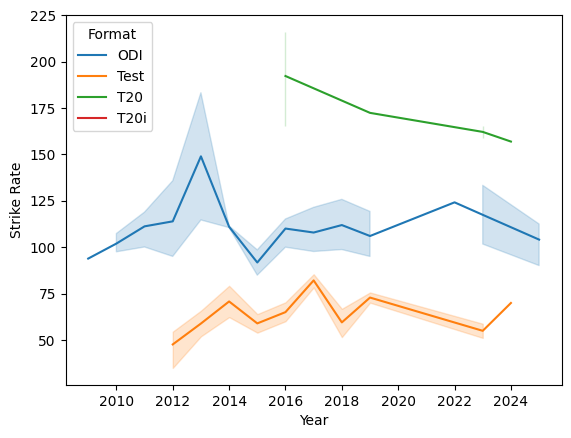

In [17]:
sns.lineplot(x="Year", y="Strike Rate", hue="Format", data=virat_dataset)
plt.show()

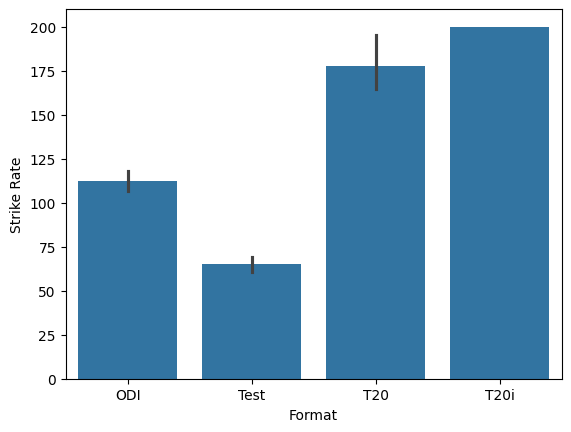

In [18]:
sns.barplot(x="Format", y="Strike Rate", data=virat_dataset)
plt.show()

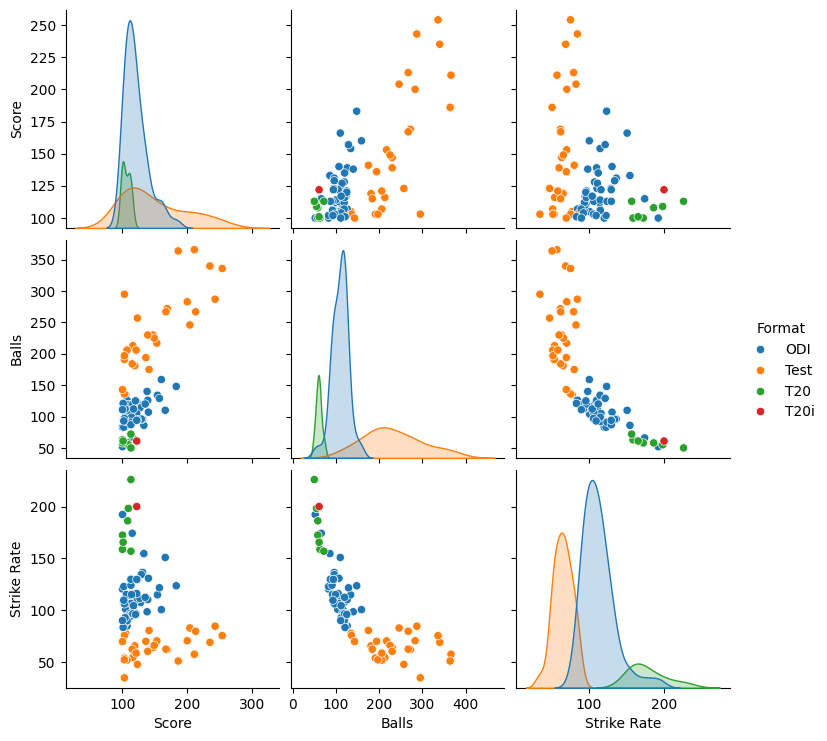

In [19]:
sns.pairplot(virat_dataset[["Score", "Balls", "Strike Rate", "Format"]], hue="Format")
plt.show()

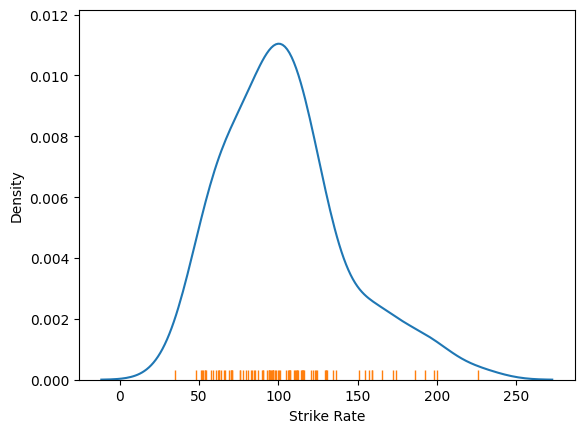

In [20]:

sns.kdeplot(data=virat_dataset, x="Strike Rate")
sns.rugplot(data=virat_dataset, x="Strike Rate")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_21340\2364878813.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=virat_dataset, x="Against", order=virat_dataset["Against"].value_counts().index, palette="viridis")


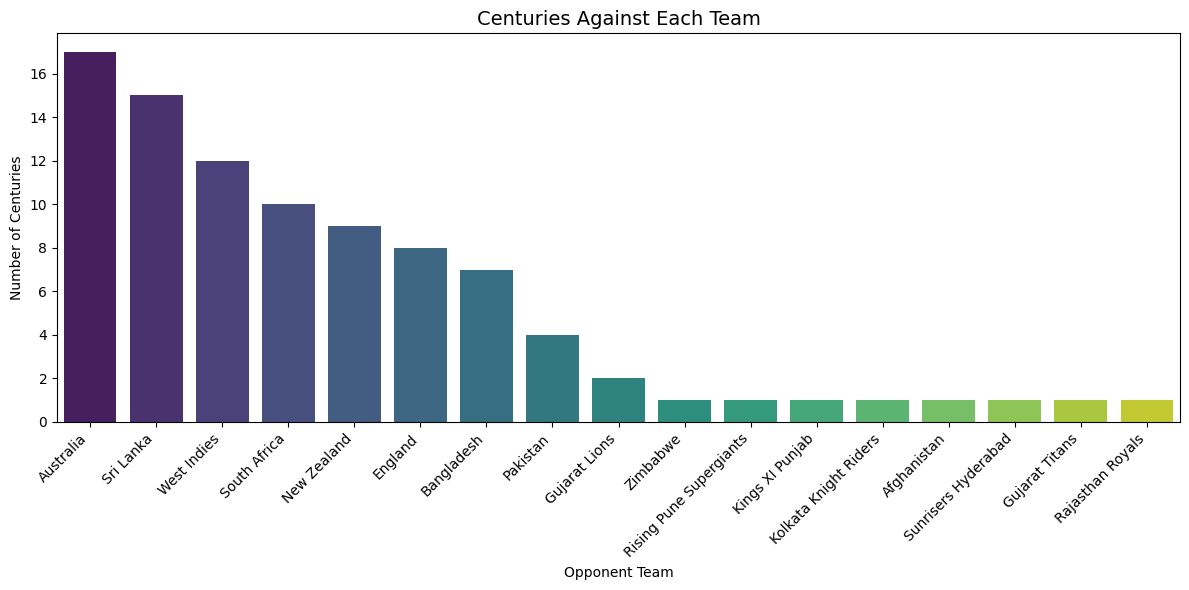

In [21]:
plt.figure(figsize=(12, 6))
sns.countplot(data=virat_dataset, x="Against", order=virat_dataset["Against"].value_counts().index, palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.title("Centuries Against Each Team", fontsize=14)
plt.xlabel("Opponent Team")
plt.ylabel("Number of Centuries")
plt.tight_layout()
plt.show()

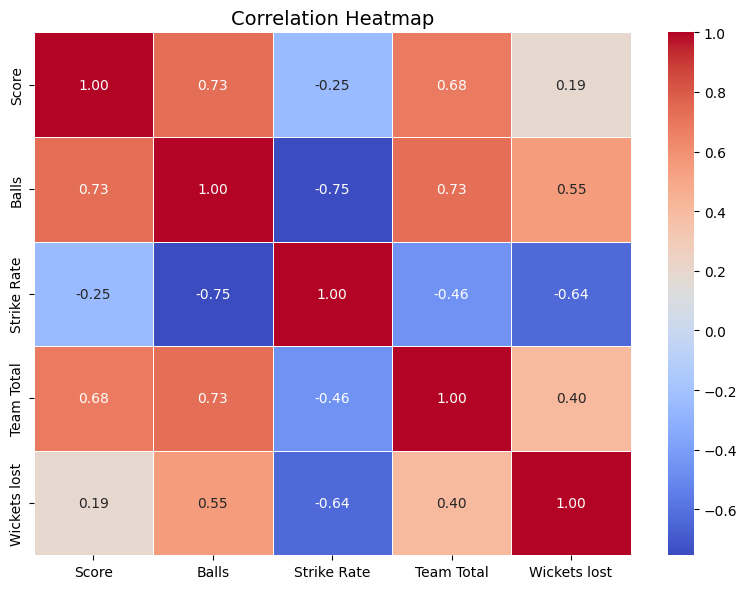

In [22]:
plt.figure(figsize=(8, 6))
corr = virat_dataset[["Score", "Balls", "Strike Rate", "Team Total", "Wickets lost"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

In [29]:
y = virat_dataset["Strike Rate"]

X = virat_dataset.drop(["Strike Rate", "Number", "Score", "Balls",
                         "Against", "Venue", "Series", "Host Nation"], axis=1)

if "Score Category" in X.columns:
    X = X.drop("Score Category", axis=1)

X = pd.get_dummies(X, columns=["Format", "Win", "Captain", "Not Out", "MOTM", "Position"], drop_first=True)

In [30]:
numeric_cols = ["Team Total", "Wickets lost", "Year", "Inning"]

preprocessor = ColumnTransformer(
    transformers=[("num", StandardScaler(), numeric_cols)],
    remainder="passthrough"
)

model = Ridge(alpha=1.0)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [37]:
y_pred = pipeline.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 17.89156011400836
R2 Score: 0.5938329595139249


In [38]:
coefficients = pd.Series(model.coef_, index=X.columns)
print(coefficients.sort_values(ascending=False))

Position_Open    37.208967
Format_T20i      20.807838
Format_T20       16.401129
Not Out_Yes       8.013293
Win_Tie           5.051094
Inning            4.690387
Win_Yes           4.491760
Wickets lost     -0.656981
Win_No           -0.933990
Captain_Yes      -1.316990
Team Total       -2.671682
Position_6       -3.426049
Position_4       -4.183906
MOTM_Yes         -6.321230
Year             -7.715420
Position_5      -17.518314
Format_Test     -38.710116
dtype: float64


In [40]:
joblib.dump(pipeline, 'virat_ridge_model.pkl')

['virat_ridge_model.pkl']